In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(os.path.abspath('../'))

from tagging_system import automate_tagging as auto_tag

In [4]:
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)
books = books.dropna() # we drop the books without descriptions because these are very, very unlikely to be winners any

In [5]:
tags = auto_tag.load_tags()
transformer = auto_tag.load_transformer()
tags_encoded = auto_tag.encode_tags()
tags_map = auto_tag.tag_dictionary()

In [6]:
books = auto_tag.encode_books(books, transformer) # takes a while

In [7]:
books = books[books.release_year >= 1971] # leaves around 20k rows

In [8]:
# manually train test split our data

books_train = books[books.release_year <= 2014]
books_test = books[books.release_year <= 2014]

books_tt = books_train[books_train.release_year <= 2005]
books_val = books_train[books_train.release_year > 2005]

In [9]:
books_tt.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",...,False,10,57,0,0,False,False,USA,Central/North America,"[-0.036100663, 0.10305314, 0.032459974, 0.0384..."
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",...,False,Unknown,48,0,0,False,False,UK,Europe,"[-0.07222478, 0.048827797, -0.00031475644, 0.0..."
4553,449,Exiled from Earth,Ben Bova,1971,1971-04-00,Berkley Books,1932,"Philadelphia, Pennsylvania, USA",0425045250,3 science fiction-romaner.\n\n,...,False,04,39,0,0,False,False,USA,Central/North America,"[-0.08211492, -0.05334223, -0.0065231794, 0.01..."
4557,13636,The Exorcist,William Peter Blatty,1971,1971-00-00,HarperPaperbacks,1928,"New York City, New York, USA",0061007226,The Exorcist is a 1971 horror novel by America...,...,False,Unknown,43,0,0,False,False,USA,Central/North America,"[-0.0025305643, 0.010534443, -0.02623904, 0.05..."
4561,13885,The Vampire Curse,Daoma Winston,1971,1971-00-00,Severn House,1922,"Washington, District of Columbia, USA",0727844490,Teena Halliday had heard rumours that Jeremy R...,...,False,Unknown,49,0,0,False,False,USA,Central/North America,"[-0.027311608, 0.05795092, 0.008173795, 0.0292..."


Here we'll just use the book synopsis encodings to form some simple models.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [10]:
models = {
    'KNN' : KNeighborsClassifier(),
    'RFC' : RandomForestClassifier(),
    'AdaBoost' : AdaBoostClassifier(),
    'GradBoost' : GradientBoostingClassifier(),
    'SVC' : SVC(),
    'XGB' : XGBClassifier()
}

In [11]:
encoded_synopsis_tt = books_tt.encoded_synopsis.explode().values.astype(float).reshape(-1, 384) # these are the hacks I need to plug the vectors in as features
encoded_synopsis_val = books_val.encoded_synopsis.explode().values.astype(float).reshape(-1, 384) # Do this first for performance reasons

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

scores = dict()
preds = dict()
# do the Locus
# this training step will take a while
for m in models:
    models[m].fit(encoded_synopsis_tt, books_tt.locus)
    pred = models[m].predict(encoded_synopsis_val) 
    preds[m] = pred

    accuracy = accuracy_score(books_val.locus, preds[m])
    f1 = f1_score(books_val.locus, preds[m])
    precision = precision_score(books_val.locus, preds[m])

    scores[m] = (accuracy, f1, precision)

scores


/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'KNN': (0.9509352959214965, 0.08571428571428572, 0.16304347826086957),
 'RFC': (0.9604415823367065, 0.0, 0.0),
 'AdaBoost': (0.9601349279362159, 0.0, 0.0),
 'GradBoost': (0.9598282735357252, 0.0, 0.0),
 'SVC': (0.9604415823367065, 0.0, 0.0),
 'XGB': (0.9590616375344986, 0.02909090909090909, 0.23529411764705882)}

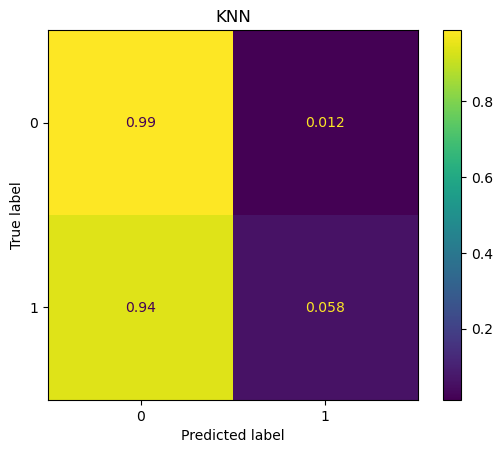

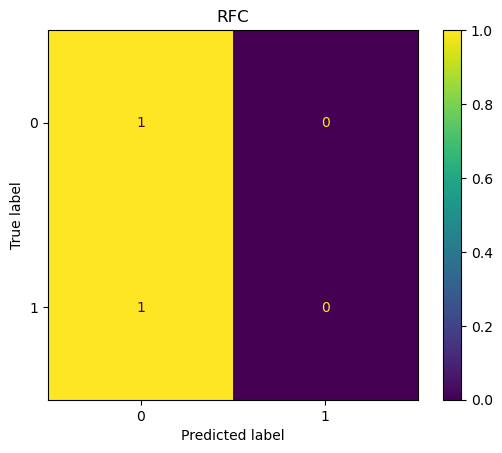

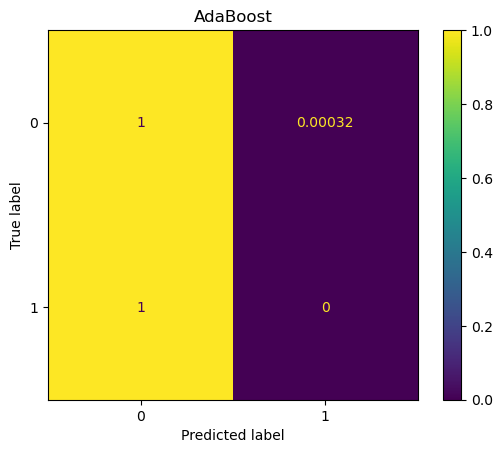

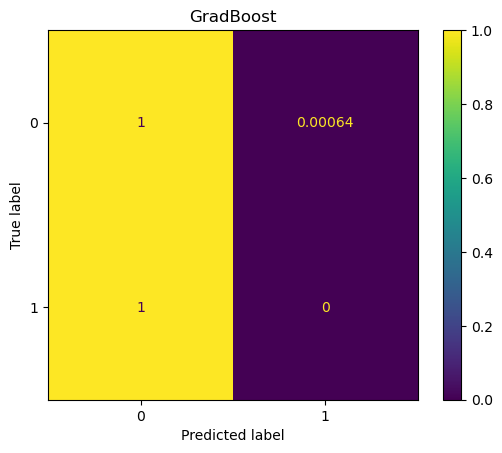

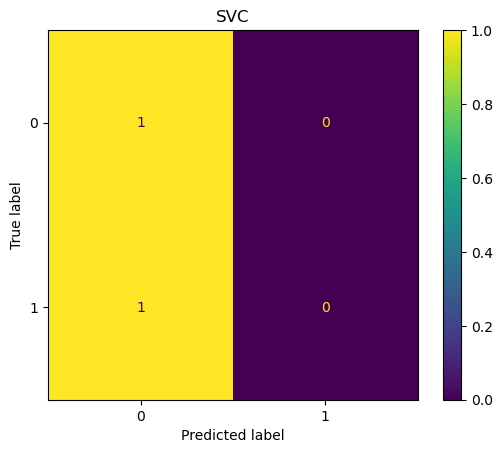

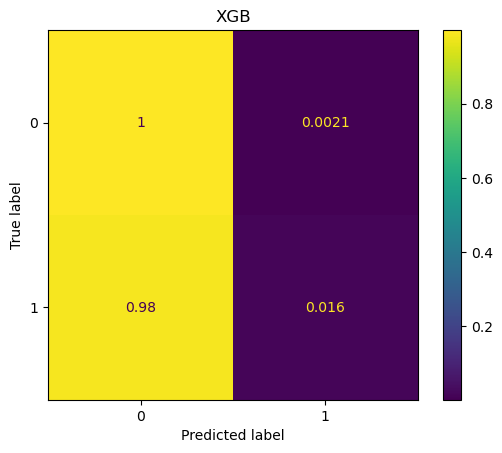

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for m in models:
    #print(m, confusion_matrix(books_val.locus, preds[m], normalize='all'))
    cm = confusion_matrix(books_val.locus, preds[m], normalize='true')
    ConfusionMatrixDisplay(cm).plot()
    plt.title(m)

    plt.show()

From the above, it seems K-Nearest Neighbors and XGB performs the best in these tests. Can then do some cross-validation to see which one actually performs the best.

In [15]:
books_train = books_train.sort_values('release_year')
books_train

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",...,False,10,57,0,0,False,False,USA,Central/North America,"[-0.036100663, 0.10305314, 0.032459974, 0.0384..."
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",...,False,Unknown,48,0,0,False,False,UK,Europe,"[-0.07222478, 0.048827797, -0.00031475644, 0.0..."
4553,449,Exiled from Earth,Ben Bova,1971,1971-04-00,Berkley Books,1932,"Philadelphia, Pennsylvania, USA",0425045250,3 science fiction-romaner.\n\n,...,False,04,39,0,0,False,False,USA,Central/North America,"[-0.08211492, -0.05334223, -0.0065231794, 0.01..."
4557,13636,The Exorcist,William Peter Blatty,1971,1971-00-00,HarperPaperbacks,1928,"New York City, New York, USA",0061007226,The Exorcist is a 1971 horror novel by America...,...,False,Unknown,43,0,0,False,False,USA,Central/North America,"[-0.0025305643, 0.010534443, -0.02623904, 0.05..."
4561,13885,The Vampire Curse,Daoma Winston,1971,1971-00-00,Severn House,1922,"Washington, District of Columbia, USA",0727844490,Teena Halliday had heard rumours that Jeremy R...,...,False,Unknown,49,0,0,False,False,USA,Central/North America,"[-0.027311608, 0.05795092, 0.008173795, 0.0292..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79615,1704582,Noggin,John Corey Whaley,2014,2014-04-08,Atheneum Books for Young Readers,1984,"Springhill, Louisiana, USA",9781442458727.0,"After dying at age 16, Travis Coates's head wa...",...,False,04,30,0,0,False,False,USA,Central/North America,"[0.03908612, 0.05395809, 0.030328972, 0.034047..."
79618,1780484,The Myth of Falling,Charlee Jacob,2014,2014-09-01,CreateSpace,1952,"Wichita Falls, Texas, USA",9781500830694.0,There is an old myth that says if one dreams o...,...,False,09,62,0,0,False,False,USA,Central/North America,"[0.04361453, -0.06802762, 0.046270356, 0.09808..."
79627,1694245,Exposure,"Kathy Reichs, Brendan Reichs",2014,2014-03-04,G. P. Putnam's Sons,1978,"Charlotte, North Carolina, USA",9781595145307.0,“If you like the TV show Bones (I do) or Maxim...,...,False,03,36,0,0,False,False,USA,Central/North America,"[-0.09108477, -0.054892004, 0.011270103, -0.11..."
79634,1786175,Yamada Monogatari: To Break the Demon Gate,Richard Parks,2014,2014-11-13,Prime Books,1955,"Newton, Mississippi, USA",9781607014416.0,Yamada no Goji is a minor nobleman of ancient ...,...,False,11,59,0,0,False,False,USA,Central/North America,"[0.010140028, 0.040249504, -0.010420635, -0.06..."


In [19]:
# manual cross_validation splitting
# kind of silly, but couldn't think of a super easy way to do it programmatically off the top of my head
tt_cv = [ books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1977)] ]
val_cv = [ books_train[(1978 <= books_train.release_year) & (books_train.release_year <= 1979)] ]

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1985)] )
val_cv.append( books_train[(1986 <= books_train.release_year) & (books_train.release_year <= 1987)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1993)] )
val_cv.append( books_train[(1994 <= books_train.release_year) & (books_train.release_year <= 1995)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 2001)] )
val_cv.append( books_train[(2002 <= books_train.release_year) & (books_train.release_year <= 2003)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 2011)] )
val_cv.append( books_train[(2012 <= books_train.release_year) & (books_train.release_year <= 2014)] )

In [20]:
knn = KNeighborsClassifier() # do the super dumb thing before trying to optimize the parameters
xgbc = XGBClassifier() # do the super dumb thing before trying to optimize the parameters

f1s = np.zeros((5, 2))
precs = np.zeros((5, 2))

# we'll first check for over/underfitting
for i in range(5):
    X_tt = tt_cv[i].encoded_synopsis.explode().values.astype(float).reshape(-1, 384)
    y_tt = tt_cv[i].locus

    knn.fit(X_tt, y_tt)
    xgbc.fit(X_tt, y_tt)

    X_val = val_cv[i].encoded_synopsis.explode().values.astype(float).reshape(-1, 384)
    y_val = val_cv[i].locus

    knn_pred = knn.predict(X_val)
    xgbc_pred = xgbc.predict(X_val)
    
    f1s[i] = (f1_score(y_val, knn_pred), f1_score(y_val, xgbc_pred))
    precs[i] = (precision_score(y_val, knn_pred), precision_score(y_val, xgbc_pred))

    

In [21]:
f1s

array([[0.09090909, 0.04878049],
       [0.12195122, 0.06153846],
       [0.07142857, 0.06896552],
       [0.175     , 0.        ],
       [0.128     , 0.01904762]])

In [22]:
precs

array([[0.33333333, 0.33333333],
       [0.2173913 , 0.33333333],
       [0.1       , 0.5       ],
       [0.30434783, 0.        ],
       [0.32      , 0.2       ]])

It seems from doing this simple cross validation, we see that XGBoost does seem to perform worse on novel data than KNN.

So maybe trying to bag and or boost, or using another model afterwards seem to be the best choice.

In [23]:
# Trying to tune the KNN model

nbrs = range(2, 11)
wts = ['uniform', 'distance']

f1s = dict()
precs = dict()


for k in nbrs:
    for w in wts:
        knn = KNeighborsClassifier(
                n_neighbors = k,
                weights = w,
                n_jobs = -1
            )
        avg_f1 = 0
        avg_prec = 0
        for i in range(5):

            X_tt = tt_cv[i].encoded_synopsis.explode().values.astype(float).reshape(-1, 384)
            y_tt = tt_cv[i].locus

            knn.fit(X_tt, y_tt)

            X_val = val_cv[i].encoded_synopsis.explode().values.astype(float).reshape(-1, 384)
            y_val = val_cv[i].locus

            knn_pred = knn.predict(X_val)

            avg_f1 += f1_score(y_val, knn_pred)
            avg_prec += precision_score(y_val, knn_pred)
            
        f1s[(k,w)] = avg_f1 / 5
        precs[(k,w)] = avg_prec / 5



/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
f1s

{(2, 'uniform'): 0.12128977387425526,
 (2, 'distance'): 0.19585271109285854,
 (3, 'uniform'): 0.15711554921679638,
 (3, 'distance'): 0.16050757139459787,
 (4, 'uniform'): 0.10153370999213177,
 (4, 'distance'): 0.15246510392713095,
 (5, 'uniform'): 0.11745777636997148,
 (5, 'distance'): 0.12608891147875317,
 (6, 'uniform'): 0.06304615211528627,
 (6, 'distance'): 0.13440384061156901,
 (7, 'uniform'): 0.07332824208868312,
 (7, 'distance'): 0.08330918876969114,
 (8, 'uniform'): 0.037445350348576156,
 (8, 'distance'): 0.10248304258825094,
 (9, 'uniform'): 0.07098415052202361,
 (9, 'distance'): 0.08212254111693594,
 (10, 'uniform'): 0.03970916487773822,
 (10, 'distance'): 0.08372126959320657}

In [25]:
precs

{(2, 'uniform'): 0.2736291486291486,
 (2, 'distance'): 0.1737798402943267,
 (3, 'uniform'): 0.20054004576659037,
 (3, 'distance'): 0.2037258534229863,
 (4, 'uniform'): 0.4814623972518709,
 (4, 'distance'): 0.20455901658909176,
 (5, 'uniform'): 0.2550144927536232,
 (5, 'distance'): 0.2648064516129032,
 (6, 'uniform'): 0.32825396825396824,
 (6, 'distance'): 0.28966810966810963,
 (7, 'uniform'): 0.30994152046783624,
 (7, 'distance'): 0.321578947368421,
 (8, 'uniform'): 0.39333333333333337,
 (8, 'distance'): 0.3495063759769642,
 (9, 'uniform'): 0.4095238095238095,
 (9, 'distance'): 0.42648351648351646,
 (10, 'uniform'): 0.31666666666666665,
 (10, 'distance'): 0.4063888888888889}

What do we learn from the above?
- Our $F_1$ scores gets better when we have smaller $k$'s and seems to do better with 'distance' weighting.
- Our precision score seems to get better for larger $k$'s, and seems to generally favor uniform weighting.

Either way, it seems our model generally doesn't do very well in either metric.

In [23]:
from sklearn.ensemble import BaggingClassifier

In [24]:
knn_bag = BaggingClassifier(
    estimator = KNeighborsClassifier(),
    n_estimators = 100,
    bootstrap = True,
    n_jobs = -1
)

knn = KNeighborsClassifier(
    n_neighbors = 2,
    weights = 'distance',
    n_jobs = -1
)

# compare BaggingClassifier against 
# our best F1 score average: n_neighbors = 2, weights = 'distance'

base_f1s = np.zeros(5)
bagged_f1s = np.zeros(5)

for i in range(5):
    X_tt = tt_cv[i].encoded_synopsis.explode().values.astype(float).reshape(-1, 384)
    y_tt = tt_cv[i].locus

    knn.fit(X_tt, y_tt)
    knn_bag.fit(X_tt, y_tt)

    X_val = val_cv[i].encoded_synopsis.explode().values.astype(float).reshape(-1, 384)
    y_val = val_cv[i].locus

    base_pred = knn.predict(X_val)
    bagged_pred = knn_bag.predict(X_val)

    base_f1s[i] = f1_score(y_val, base_pred)
    bagged_f1s[i] = f1_score(y_val, bagged_pred)

print('Base average F1:', np.mean(base_f1s))
print('Bagged average F1:', np.mean(bagged_f1s)) 

Base average F1: 0.19585271109285854
Bagged average F1: 0.11394478397372154


So our bagged F1s actually went down... whoops

This must means that we were actually quite underfitting originally.

This should probably confirm our intuitions that you can't just judge the quality of a book by its synopsis!

Do the same tests for the Hugo award. 

I believe we should expect even lower scores because the Hugo award data set is even sparser than the Locus one.

In [25]:
scores = dict()
preds = dict()
# do the Locus
# this training step will take a while
for m in models:
    models[m].fit(encoded_synopsis_tt, books_tt.hugo)
    pred = models[m].predict(encoded_synopsis_val) 
    preds[m] = pred

    accuracy = accuracy_score(books_val.hugo, preds[m])
    f1 = f1_score(books_val.locus, preds[m])
    precision = precision_score(books_val.hugo, preds[m])

    scores[m] = (accuracy, f1, precision)

scores


/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

{'KNN': (0.9950935295921497, 0.0, 0.0),
 'RFC': (0.995246856792395, 0.0, 0.0),
 'AdaBoost': (0.9940202391904324, 0.0, 0.0),
 'GradBoost': (0.9863538791781662, 0.006329113924050633, 0.0),
 'SVC': (0.995246856792395, 0.0, 0.0),
 'XGB': (0.995246856792395, 0.0, 0.0)}

So as expected, the performance on the Hugo data set is much worse than the performance of the Locus data set due to the higher sparsity of the Hugo nominees. Interestingly, in terms of $F_1$-score, GradientBoost seems to does better than $k$-NN and XGB, though the scores are so small that they really are just identical.